In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import pandas as pd
%matplotlib inline

In [4]:
X,y= make_blobs(n_samples=1000,centers=3,n_features=2)

In [5]:
X

array([[-4.64621129,  6.17524654],
       [-4.2270964 ,  6.14752376],
       [-6.47790311, -1.73789538],
       ...,
       [-2.50141915,  3.36719165],
       [-2.46791136,  2.51655267],
       [-3.25368603,  1.82979657]], shape=(1000, 2))

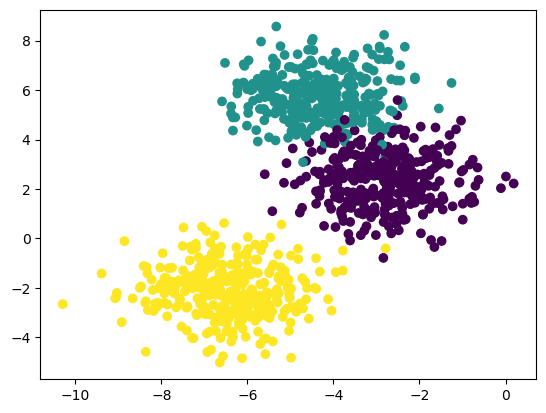

In [8]:
plt.scatter(X[:,0],X[:,1],c=y)

In [10]:
#Stanaardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [12]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.cluster import KMeans

In [14]:
#Elbow Method
wcss = []
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\NIRAJ\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\NIRAJ\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\NIRAJ\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\NIRAJ\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [15]:
wcss

[1339.9999999999995,
 448.2808753952467,
 403.7091672171748,
 195.52995162168705,
 180.8768820012533,
 127.63701652528539,
 115.52302155860863,
 101.19716117156912,
 98.24050715639729,
 84.87520539916648]

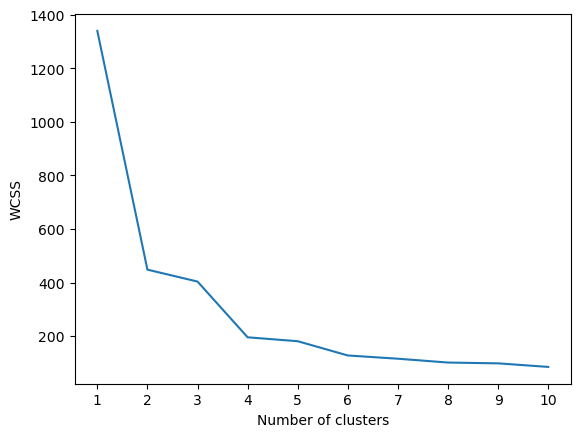

In [18]:
#PLot Elbow Curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [19]:
kmeans=KMeans(n_clusters=3,init='k-means++')
kmeans.fit_predict(X_train)

C:\Users\NIRAJ\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([1, 1, 1, 2, 1, 1, 0, 0, 1, 0, 0, 2, 2, 2, 2, 1, 2, 0, 1, 2, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 2, 2, 1, 2, 0, 0, 0, 1, 0, 1, 2, 2, 2, 1,
       2, 0, 0, 1, 1, 1, 1, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 2, 0, 1, 0, 2,
       2, 0, 2, 2, 0, 1, 0, 2, 0, 1, 1, 1, 1, 2, 1, 2, 0, 1, 0, 0, 0, 1,
       2, 1, 1, 2, 1, 0, 2, 0, 1, 0, 2, 0, 0, 1, 2, 1, 0, 2, 1, 0, 0, 0,
       1, 1, 2, 0, 0, 0, 2, 1, 0, 0, 1, 2, 2, 0, 0, 2, 2, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 2, 1, 1, 2, 1, 2, 2, 0, 1, 0, 2, 0, 0, 0, 1, 0,
       0, 0, 2, 2, 0, 1, 0, 0, 2, 2, 0, 2, 2, 0, 0, 1, 2, 2, 1, 0, 1, 1,
       1, 0, 0, 2, 2, 1, 2, 1, 0, 0, 0, 1, 0, 2, 0, 2, 0, 0, 1, 2, 1, 0,
       2, 0, 1, 0, 0, 0, 0, 1, 2, 1, 1, 2, 1, 1, 0, 1, 1, 0, 1, 1, 2, 1,
       2, 2, 1, 0, 1, 1, 0, 2, 2, 0, 0, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       2, 0, 2, 1, 1, 2, 0, 1, 2, 1, 2, 2, 1, 2, 0, 1, 2, 2, 0, 0, 0, 0,
       0, 0, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 1, 1, 1, 1, 0, 2, 0, 1, 0,
       1, 2, 1, 2, 1, 2, 2, 1, 1, 0, 0, 1, 1, 0, 0,

In [20]:
y_pred = kmeans.predict(X_test)

In [21]:
y_pred

array([0, 0, 1, 1, 1, 2, 0, 1, 2, 1, 0, 2, 0, 2, 1, 1, 0, 1, 1, 1, 2, 1,
       2, 0, 2, 2, 1, 2, 2, 0, 1, 0, 0, 2, 0, 1, 2, 2, 0, 1, 0, 0, 1, 1,
       2, 0, 0, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 0, 1, 2, 2, 1, 2, 0, 2, 0,
       1, 0, 1, 2, 2, 2, 2, 0, 0, 1, 2, 1, 0, 2, 2, 1, 1, 0, 0, 2, 2, 1,
       2, 0, 0, 1, 1, 2, 0, 0, 2, 0, 1, 1, 1, 1, 0, 1, 1, 2, 1, 2, 2, 1,
       1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 0, 1, 0, 0, 2, 2, 0, 1,
       0, 1, 2, 1, 2, 0, 1, 0, 1, 1, 2, 2, 0, 0, 1, 1, 2, 1, 0, 1, 2, 1,
       0, 1, 1, 1, 0, 2, 2, 2, 1, 0, 2, 1, 2, 1, 0, 1, 0, 0, 2, 1, 2, 1,
       0, 2, 2, 2, 0, 0, 2, 0, 1, 2, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 2,
       0, 2, 1, 2, 1, 0, 1, 0, 2, 0, 1, 0, 1, 0, 1, 2, 0, 2, 0, 1, 0, 1,
       1, 2, 0, 2, 2, 0, 2, 1, 2, 1, 2, 2, 1, 1, 0, 1, 0, 2, 0, 1, 0, 0,
       0, 0, 2, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 0, 0, 1, 0, 1, 2, 0, 2, 1,
       0, 2, 1, 0, 2, 2, 0, 1, 2, 1, 0, 0, 0, 0, 1, 2, 2, 0, 1, 0, 0, 0,
       1, 0, 0, 2, 2, 1, 1, 0, 0, 2, 0, 2, 2, 2, 0,

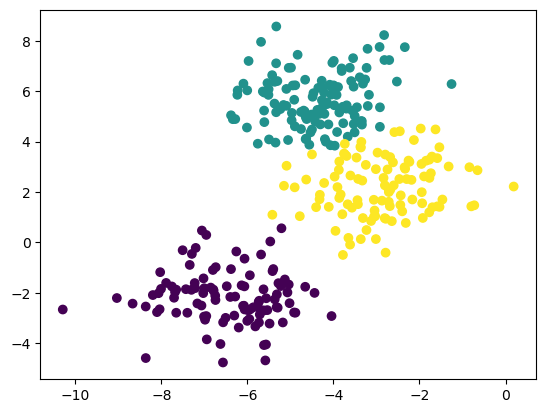

In [23]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [24]:
#Validate the K-Values
#Kneelocator'
#Silhotee Scoring

In [25]:
!pip install kneed

In [26]:
from kneed import KneeLocator

In [28]:
kl = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [29]:
kl.elbow

np.int64(4)

In [31]:
#Silhotee Scoring
from sklearn.metrics import silhouette_score

In [36]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans= KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score =silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

C:\Users\NIRAJ\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\NIRAJ\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\NIRAJ\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\NIRAJ\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [37]:
silhouette_coefficients

[0.6066452585319754,
 0.4677483307809459,
 0.4600391200739124,
 0.3906564577026617,
 0.3752091076725531,
 0.3641101241619867,
 0.3515187761501592,
 0.3388430959613772,
 0.3577564083930452]

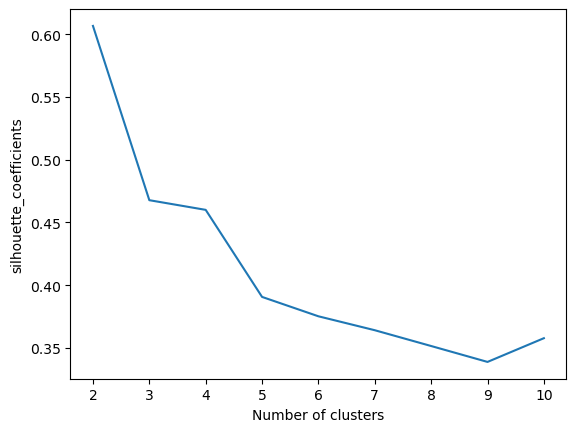

In [38]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("silhouette_coefficients")
plt.show()